# Majority Voting Approach

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier, 
    BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [2]:
CLASSIFIERS = {
    'DT': DecisionTreeClassifier(random_state=42),
    'RF': RandomForestClassifier(n_estimators=10, random_state=42),
    'Ensemble-GB': GradientBoostingClassifier(random_state=42),
    'Ensemble-AB': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42), 
        n_estimators=50, 
        random_state=42,
        algorithm='SAMME'
    ),
    'Ensemble-Bg': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=10,
        random_state=42
    ),
    'SVM-Linear': SVC(kernel='linear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'SVM-Sigmoid': SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42),
    'MLP-500': MLPClassifier(hidden_layer_sizes=(500,), max_iter=1000, random_state=42),
    'MLP-100-100-100': MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=1000, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'NearestCentroid': NearestCentroid(),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}

## Load Data

In [3]:
TEST_SIZE = 0.2
N_RUNS = 10
RANDOM_STATE = 42

METRIC_NAMES = [
    'f1', 'f1v', 'f2', 'f3', 'f4', 'l1', 'l2', 'l3',
    'n1', 'n2', 'n3', 'n4', 't1', 'lsc', 'density',
    'clsCoef', 'hubs', 't2', 't3', 't4', 'c1', 'c2',
    'kolmogorov', 'intrinsic'
]

In [4]:
synthesis_df = pd.read_csv("results/synthesis_df with load_data.csv", index_col=0)
task1a_labels = pd.read_csv("results/taska_labels with load_data.csv")
task1b_labels = pd.read_csv("results/taskb_labels with load_data.csv")

print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Synthesis DataFrame: {synthesis_df.shape}")
print(f"Task-A Labels: {len(task1a_labels)}")
print(f"Task-B Labels: {len(task1b_labels)}")
print(f"\nFeatures: {len(synthesis_df.columns) - 1}")
print(f"Unique Kernels: {task1a_labels['Best_Kernel'].nunique()}")
print("\nKernel Distribution (Task-A):")
print(task1a_labels['Best_Kernel'].value_counts())
print("\nKernel Distribution (Task-B):")
print(task1b_labels['Best_Kernel'].value_counts())

DATA SUMMARY
Synthesis DataFrame: (200, 25)
Task-A Labels: 200
Task-B Labels: 483

Features: 24
Unique Kernels: 8

Kernel Distribution (Task-A):
Best_Kernel
HighDim                116
ZFeatureMap             28
SeparableRX             25
ZZFeatureMap            15
HardwareEfficientRx      7
HZY_CZ                   6
ParamZFeatureMap         2
YZ_CX                    1
Name: count, dtype: int64

Kernel Distribution (Task-B):
Best_Kernel
HighDim                119
SeparableRX             94
HardwareEfficientRx     84
ZFeatureMap             75
HZY_CZ                  62
ZZFeatureMap            44
ParamZFeatureMap         3
YZ_CX                    1
Chebyshev                1
Name: count, dtype: int64


## Core Functions

Hệ thống Majority Voting sử dụng 14 classifiers cổ điển. Quy trình gồm 2 bước:
1. `train_all_classifiers`: huấn luyện toàn bộ 14 classifiers trên cùng một tập (X_train, y_train). Mỗi classifier được clone trước khi fit để tránh side effects.
2. `predict_majority_vote`: với mỗi sample, thu thập prediction từ tất cả classifiers, rồi chọn label có số phiếu cao nhất (most_common) làm kết quả cuối cùng.

`predict_with_details` là phiên bản mở rộng của `predict_majority_vote`, trả về thêm prediction của từng classifier và phân bố phiếu bầu — dùng cho mục đích phân tích và debug.

In [5]:
def predict_majority_vote(X, trained_models):
    all_predictions = []
    for i in range(X.shape[0]):
        votes = []
        for name, model in trained_models.items():
            pred = model.predict(X[i:i+1])[0]
            votes.append(pred)
        vote_counts = Counter(votes) # calculate the frequency of each labels
        majority = vote_counts.most_common(1)[0][0]
        all_predictions.append(majority)
    return np.array(all_predictions)

def predict_with_details(X_single, trained_models, label_encoder):
    individual_preds = {}
    votes = []
    for name, model in trained_models.items():
        pred_encoded = model.predict(X_single.reshape(1, -1))[0]
        pred_label = label_encoder.inverse_transform([pred_encoded])[0]
        individual_preds[name] = pred_label
        votes.append(pred_encoded)
    
    vote_counts = Counter(votes)
    majority_encoded = vote_counts.most_common(1)[0][0]
    majority_label = label_encoder.inverse_transform([majority_encoded])[0]
    vote_labels = Counter([label_encoder.inverse_transform([v])[0] for v in votes])
    
    return majority_label, individual_preds, dict(vote_labels)

def train_all_classifiers(X_train, y_train):
    trained = {}
    for name, clf in CLASSIFIERS.items():
        try:
            model = clone(clf)
            model.fit(X_train, y_train)
            trained[name] = model
        except:
            pass
    return trained

## Task-A: Data Preparation

Mỗi dataset tương ứng với đúng 1 label duy nhất — kernel đạt accuracy cao nhất (best kernel). Features là 24 complexity metrics từ `synthesis_df`.

Rare kernels là các kernel có ít hơn 2 samples trong toàn bộ tập dữ liệu. Những samples thuộc rare kernels sẽ được xử lý đặc biệt khi split: luôn đưa vào tập train (không thể stratify với chỉ 1 sample).

In [6]:
print("=" * 60)
print("TASK-A: DATA PREPARATION")
print("=" * 60)

feature_cols = [col for col in synthesis_df.columns if col != 'Best_Kernel']

X_1a = synthesis_df[feature_cols].values
y_1a = task1a_labels.set_index('Dataset').loc[synthesis_df.index, 'Best_Kernel'].values
names_1a = synthesis_df.index.tolist()

kernel_counts_1a = pd.Series(y_1a).value_counts()
rare_kernels_1a = kernel_counts_1a[kernel_counts_1a < 2].index.tolist()

le_1a = LabelEncoder()
y_1a_encoded = le_1a.fit_transform(y_1a)

print(f"X shape: {X_1a.shape}")
print(f"y shape: {y_1a_encoded.shape}")
print(f"Classes: {list(le_1a.classes_)}")
print(f"Rare kernels (< 2 samples): {rare_kernels_1a}")

TASK-A: DATA PREPARATION
X shape: (200, 24)
y shape: (200,)
Classes: ['HZY_CZ', 'HardwareEfficientRx', 'HighDim', 'ParamZFeatureMap', 'SeparableRX', 'YZ_CX', 'ZFeatureMap', 'ZZFeatureMap']
Rare kernels (< 2 samples): ['YZ_CX']


### Task-A: Single Metric Evaluation

Đánh giá khả năng recommendation khi chỉ dùng 1 metric làm feature duy nhất. Mỗi metric được đánh giá độc lập qua N_RUNS lần (mỗi lần với random_state khác nhau) để tính mean accuracy ± std.

Quy trình mỗi run:
- Tách rare kernels ra khỏi tập common → stratified split trên tập common → gộp rare kernels vào tập train
- StandardScaler fit trên train, transform trên test (không data leakage)
- Train 14 classifiers → Majority Voting → accuracy trên test set

Kết quả cho phép xác định metric nào đơn lẻ đã có khả năng phân biệt tốt giữa các kernel classes, đồng thời so sánh với trường hợp dùng toàn bộ 24 metrics.

In [7]:
def evaluate_single_metric_1a(X, y_encoded, y_labels, rare_kernels, metric_idx, n_runs=10):
    """Evaluate single metric for Task 1-A"""
    accs = []
    for run in range(n_runs):
        X_single = X[:, [metric_idx]]
        
        # Handle rare kernels
        rare_mask = np.isin(y_labels, rare_kernels)
        X_rare, y_rare = X_single[rare_mask], y_encoded[rare_mask]
        X_common, y_common = X_single[~rare_mask], y_encoded[~rare_mask]
        
        X_tr_c, X_te, y_tr_c, y_te = train_test_split(
            X_common, y_common, test_size=TEST_SIZE, random_state=run, stratify=y_common
        )
        
        X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
        y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        accs.append(accuracy_score(y_te, y_pred))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-A: SINGLE METRIC EVALUATION")
print("=" * 60)

results_1a_single = []
total_start = time.time()

for idx, metric in enumerate(METRIC_NAMES):
    start = time.time()
    mean_acc, std_acc = evaluate_single_metric_1a(
        X_1a, y_1a_encoded, y_1a, rare_kernels_1a, idx, n_runs=N_RUNS
    )
    elapsed = time.time() - start
    results_1a_single.append({
        'Metric': metric,
        'Mean_Acc': mean_acc,
        'Std_Acc': std_acc,
        'Time_s': round(elapsed, 2)
    })
    print(f"  {metric:15s}: {mean_acc:.4f} ± {std_acc:.4f}  ({elapsed:.2f}s)")

total_elapsed = time.time() - total_start
print(f"\nTotal time: {total_elapsed:.2f}s ({total_elapsed/60:.1f} min)")

df_1a_single = pd.DataFrame(results_1a_single).sort_values('Mean_Acc', ascending=False)

TASK-A: SINGLE METRIC EVALUATION
  f1             : 0.6725 ± 0.0439  (19.14s)
  f1v            : 0.6925 ± 0.0297  (18.67s)
  f2             : 0.6025 ± 0.0361  (18.47s)
  f3             : 0.5975 ± 0.0425  (17.64s)
  f4             : 0.6125 ± 0.0321  (20.07s)
  l1             : 0.6000 ± 0.0536  (29.53s)
  l2             : 0.7000 ± 0.0250  (31.06s)
  l3             : 0.6075 ± 0.0448  (30.16s)
  n1             : 0.5450 ± 0.0444  (35.00s)
  n2             : 0.5475 ± 0.0261  (28.13s)
  n3             : 0.5200 ± 0.0350  (36.65s)
  n4             : 0.6375 ± 0.0358  (32.38s)
  t1             : 0.5325 ± 0.0488  (33.40s)
  lsc            : 0.5300 ± 0.0458  (31.00s)
  density        : 0.5850 ± 0.0539  (31.16s)
  clsCoef        : 0.5550 ± 0.0150  (32.45s)
  hubs           : 0.5925 ± 0.0372  (31.70s)
  t2             : 0.5950 ± 0.0100  (31.24s)
  t3             : 0.5900 ± 0.0166  (32.19s)
  t4             : 0.5750 ± 0.0000  (10.29s)
  c1             : 0.6575 ± 0.0317  (18.77s)
  c2             : 0.6

### Task-A: All Metrics

### Task-A: All Metrics Evaluation

Sử dụng toàn bộ 24 complexity metrics làm feature vector. Quy trình tương tự Single Metric nhưng X giữ nguyên toàn bộ cột (không chọn subset).

Kết quả ALL_METRICS được append vào bảng so sánh `df_1a_single` để có thể đối chiếu trực tiếp: liệu dùng tất cả metrics có thực sự tốt hơn chỉ dùng 1 metric đơn lẻ tốt nhất hay không (curse of dimensionality với small sample size).

In [8]:
def evaluate_all_metrics_1a(X, y_encoded, y_labels, rare_kernels, n_runs=10):
    """Evaluate all metrics for Task 1-A"""
    accs = []
    for run in range(n_runs):
        rare_mask = np.isin(y_labels, rare_kernels)
        X_rare, y_rare = X[rare_mask], y_encoded[rare_mask]
        X_common, y_common = X[~rare_mask], y_encoded[~rare_mask]
        
        X_tr_c, X_te, y_tr_c, y_te = train_test_split(
            X_common, y_common, test_size=TEST_SIZE, random_state=run, stratify=y_common
        )
        
        X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
        y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        accs.append(accuracy_score(y_te, y_pred))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-A: ALL METRICS EVALUATION")
print("=" * 60)

total_start = time.time()

mean_all_1a, std_all_1a = evaluate_all_metrics_1a(
    X_1a, y_1a_encoded, y_1a, rare_kernels_1a, n_runs=N_RUNS
)

total_elapsed = time.time() - total_start
print(f"  ALL_METRICS: {mean_all_1a:.4f} ± {std_all_1a:.4f}  ({total_elapsed:.2f}s / {total_elapsed/60:.1f} min)")

df_1a_single = pd.concat([
    df_1a_single,
    pd.DataFrame([{'Metric': 'ALL_METRICS', 'Mean_Acc': mean_all_1a, 'Std_Acc': std_all_1a, 'Time_s': round(total_elapsed, 2)}])
], ignore_index=True).sort_values('Mean_Acc', ascending=False)

TASK-A: ALL METRICS EVALUATION
  ALL_METRICS: 0.7250 ± 0.0447  (31.90s / 0.5 min)


Task-B: Data Preparation
========================
Khác với Task-A (mỗi dataset chỉ có đúng 1 label duy nhất), Task-B cho phép mỗi dataset có nhiều hơn 1 label (tức nhiều kernels cùng đạt accuracy cao nhất trong ngưỡng tolerance, ngưỡng này được ta fixed là 1% ở file `Quantum Learning`).

Do đó, mỗi dataset được "expand" thành nhiều samples — mỗi sample ứng với 1 kernel trong tập best kernels của dataset đó. Kết quả là X_1b có số dòng lớn hơn số datasets gốc.

Các samples được group theo tên dataset để đảm bảo không bị data leakage khi split train/test (dùng GroupShuffleSplit thay vì StratifiedKFold).

In [9]:
print("=" * 60)
print("TASK-B: DATA PREPARATION")
print("=" * 60)

dataset_to_valid_kernels = task1b_labels.groupby('Dataset')['Best_Kernel'].apply(set).to_dict()

X_1b_list = []
y_1b_list = []
names_1b = []

for dataset_name in synthesis_df.index:
    if dataset_name in dataset_to_valid_kernels:
        features = synthesis_df.loc[dataset_name, feature_cols].values
        for kernel in dataset_to_valid_kernels[dataset_name]:
            X_1b_list.append(features)
            y_1b_list.append(kernel)
            names_1b.append(dataset_name)

X_1b = np.array(X_1b_list)
y_1b = np.array(y_1b_list)

le_1b = LabelEncoder()
y_1b_encoded = le_1b.fit_transform(y_1b)

kernel_counts_1b = pd.Series(y_1b).value_counts()
rare_kernels_1b = kernel_counts_1b[kernel_counts_1b < 2].index.tolist()

print(f"X shape: {X_1b.shape}")
print(f"y shape: {y_1b_encoded.shape}")
print(f"Classes: {list(le_1b.classes_)}")
print(f"Rare kernels: {rare_kernels_1b}")


TASK-B: DATA PREPARATION
X shape: (483, 24)
y shape: (483,)
Classes: [np.str_('Chebyshev'), np.str_('HZY_CZ'), np.str_('HardwareEfficientRx'), np.str_('HighDim'), np.str_('ParamZFeatureMap'), np.str_('SeparableRX'), np.str_('YZ_CX'), np.str_('ZFeatureMap'), np.str_('ZZFeatureMap')]
Rare kernels: ['Chebyshev', 'YZ_CX']


### Task-B: Single Metric Evaluation

Tương tự Task-A Single Metric, nhưng với cách đánh giá accuracy khác biệt quan trọng:

Ở Task-A, prediction đúng khi pred == label duy nhất. Ở Task-B, prediction được tính là đúng nếu kernel được dự đoán nằm trong **tập valid kernels** của dataset đó (tức các kernels đạt accuracy trong ngưỡng tolerance so với best kernel).

Do đó, hàm cần thêm tham số `names` (tên dataset tương ứng mỗi sample) và `valid_kernels_dict` để tra cứu tập valid kernels khi tính accuracy. Phần split vẫn xử lý rare kernels tương tự Task-A.

Lưu ý: ở đây dùng `train_test_split` với `stratify` thay vì `GroupShuffleSplit`. Điều này có nghĩa các expanded samples từ cùng một dataset có thể rơi vào cả train và test — một điểm cần cân nhắc về data leakage tiềm ẩn.

In [10]:
def evaluate_single_metric_1b(X, y_encoded, y_labels, names, valid_kernels_dict, le, metric_idx, n_runs=10):
    accs = []
    
    kernel_counts = pd.Series(y_labels).value_counts()
    rare_k = kernel_counts[kernel_counts < 2].index.tolist()
    
    for run in range(n_runs):
        X_single = X[:, [metric_idx]]
        
        if rare_k:
            rare_mask = np.isin(y_labels, rare_k)
            X_rare, y_rare = X_single[rare_mask], y_encoded[rare_mask]
            X_common, y_common = X_single[~rare_mask], y_encoded[~rare_mask]
            names_common = np.array(names)[~rare_mask]
            
            X_tr_c, X_te, y_tr_c, y_te, _, names_te = train_test_split(
                X_common, y_common, names_common,
                test_size=TEST_SIZE, random_state=run, stratify=y_common
            )
            
            X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
            y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        else:
            X_tr, X_te, y_tr, y_te, _, names_te = train_test_split(
                X_single, y_encoded, np.array(names),
                test_size=TEST_SIZE, random_state=run, stratify=y_encoded
            )
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        
        correct = 0
        for pred, ds_name in zip(y_pred, names_te):
            pred_label = le.inverse_transform([pred])[0]
            if pred_label in valid_kernels_dict.get(ds_name, set()):
                correct += 1
        
        accs.append(correct / len(y_te))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-B: SINGLE METRIC EVALUATION")
print("=" * 60)

results_1b_single = []
total_start = time.time()

for idx, metric in enumerate(METRIC_NAMES):
    start = time.time()
    mean_acc, std_acc = evaluate_single_metric_1b(
        X_1b, y_1b_encoded, y_1b, names_1b, 
        dataset_to_valid_kernels, le_1b, idx, n_runs=N_RUNS
    )
    elapsed = time.time() - start
    results_1b_single.append({
        'Metric': metric,
        'Mean_Acc': mean_acc,
        'Std_Acc': std_acc,
        'Time_s': round(elapsed, 2)
    })
    print(f"  {metric:15s}: {mean_acc:.4f} ± {std_acc:.4f}  ({elapsed:.2f}s)")

total_elapsed = time.time() - total_start
print(f"\nTotal time: {total_elapsed:.2f}s ({total_elapsed/60:.1f} min)")

df_1b_single = pd.DataFrame(results_1b_single).sort_values('Mean_Acc', ascending=False)

best_singlemetric_1b = df_1b_single.iloc[0]['Metric']
best_singlemetric_1b_acc = df_1b_single.iloc[0]['Mean_Acc']
best_singlemetric_1b_std = df_1b_single.iloc[0]['Std_Acc']

print(f"\n{'='*60}")
print(f"BEST SINGLE METRIC (Task 1-B): {best_singlemetric_1b}")
print(f"Accuracy: {best_singlemetric_1b_acc:.4f} ± {best_singlemetric_1b_std:.4f}")
print(f"Total time: {total_elapsed:.2f}s ({total_elapsed/60:.1f} min)")
print(f"{'='*60}")

TASK-B: SINGLE METRIC EVALUATION
  f1             : 0.8670 ± 0.0370  (48.40s)
  f1v            : 0.8639 ± 0.0335  (35.34s)
  f2             : 0.8423 ± 0.0336  (26.48s)
  f3             : 0.8474 ± 0.0341  (39.78s)
  f4             : 0.8402 ± 0.0320  (46.61s)
  l1             : 0.8474 ± 0.0283  (62.43s)
  l2             : 0.8629 ± 0.0326  (48.15s)
  l3             : 0.8670 ± 0.0286  (45.71s)
  n1             : 0.7866 ± 0.0375  (43.65s)
  n2             : 0.8000 ± 0.0346  (42.82s)
  n3             : 0.7701 ± 0.0295  (39.69s)
  n4             : 0.8474 ± 0.0200  (47.65s)
  t1             : 0.7990 ± 0.0459  (33.79s)
  lsc            : 0.8237 ± 0.0346  (43.10s)
  density        : 0.8495 ± 0.0262  (42.29s)
  clsCoef        : 0.7948 ± 0.0300  (46.94s)
  hubs           : 0.8052 ± 0.0286  (51.28s)
  t2             : 0.7948 ± 0.0424  (41.68s)
  t3             : 0.7959 ± 0.0280  (43.92s)
  t4             : 0.7928 ± 0.0321  (31.72s)
  c1             : 0.8175 ± 0.0306  (37.92s)
  c2             : 0.8

### Task-B: All Metrics Evaluation

Sử dụng toàn bộ 24 complexity metrics làm features, với cùng cơ chế đánh giá accuracy theo tập valid kernels như Task-B Single Metric.

Kết quả ALL_METRICS được append vào bảng `df_1b_single` để so sánh trực tiếp với từng single metric. Tương tự Task-A, đây là cơ sở để kiểm tra liệu curse of dimensionality có ảnh hưởng khi số samples (sau expand) vẫn còn hạn chế so với 24 features.

In [11]:
def evaluate_all_metrics_1b(X, y_encoded, y_labels, names, valid_kernels_dict, le, n_runs=10):
    accs = []
    
    kernel_counts = pd.Series(y_labels).value_counts()
    rare_k = kernel_counts[kernel_counts < 2].index.tolist()
    
    for run in range(n_runs):
        if rare_k:
            rare_mask = np.isin(y_labels, rare_k)
            X_rare, y_rare = X[rare_mask], y_encoded[rare_mask]
            X_common, y_common = X[~rare_mask], y_encoded[~rare_mask]
            names_common = np.array(names)[~rare_mask]
            
            X_tr_c, X_te, y_tr_c, y_te, _, names_te = train_test_split(
                X_common, y_common, names_common,
                test_size=TEST_SIZE, random_state=run, stratify=y_common
            )
            
            X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
            y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        else:
            X_tr, X_te, y_tr, y_te, _, names_te = train_test_split(
                X, y_encoded, np.array(names),
                test_size=TEST_SIZE, random_state=run, stratify=y_encoded
            )
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        
        correct = 0
        for pred, ds_name in zip(y_pred, names_te):
            pred_label = le.inverse_transform([pred])[0]
            if pred_label in valid_kernels_dict.get(ds_name, set()):
                correct += 1
        
        accs.append(correct / len(y_te))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-B: ALL METRICS EVALUATION")
print("=" * 60)

start = time.time()
mean_all_1b, std_all_1b = evaluate_all_metrics_1b(
    X_1b, y_1b_encoded, y_1b, names_1b, 
    dataset_to_valid_kernels, le_1b, n_runs=N_RUNS
)
elapsed = time.time() - start
print(f"  ALL_METRICS: {mean_all_1b:.4f} ± {std_all_1b:.4f}  ({elapsed:.2f}s / {elapsed/60:.1f} min)")

df_1b_single = pd.concat([
    df_1b_single,
    pd.DataFrame([{'Metric': 'ALL_METRICS', 'Mean_Acc': mean_all_1b, 'Std_Acc': std_all_1b, 'Time_s': round(elapsed, 2)}])
], ignore_index=True).sort_values('Mean_Acc', ascending=False)

TASK-B: ALL METRICS EVALUATION
  ALL_METRICS: 0.9196 ± 0.0260  (70.62s / 1.2 min)


## Save & Preview Results

Lưu bảng kết quả của cả Task-A và Task-B ra file CSV để sử dụng cho các bước phân tích tiếp theo (vẽ biểu đồ, so sánh với LOOCV, viết paper). Mỗi file chứa accuracy và std của từng single metric cùng với ALL_METRICS, đã được sắp xếp theo Mean_Acc giảm dần.

In [12]:
df_1a_single.to_csv("results/mv_taska_results.csv", index=False)
df_1b_single.to_csv("results/mv_taskb_results.csv", index=False)

print("Saved:")
print(f"  results/mv_taska_results.csv  ({len(df_1a_single)} rows)")
print(f"  results/mv_taskb_results.csv  ({len(df_1b_single)} rows)")
print()
print("Task-A preview:")
print(df_1a_single[['Metric', 'Mean_Acc', 'Std_Acc']].to_string(index=False))
print()
print("Task-B preview:")
print(df_1b_single[['Metric', 'Mean_Acc', 'Std_Acc']].to_string(index=False))

Saved:
  results/mv_taska_results.csv  (25 rows)
  results/mv_taskb_results.csv  (25 rows)

Task-A preview:
     Metric  Mean_Acc  Std_Acc
ALL_METRICS    0.7250 0.044721
         l2    0.7000 0.025000
        f1v    0.6925 0.029686
         f1    0.6725 0.043946
         c1    0.6575 0.031721
         c2    0.6575 0.031721
         n4    0.6375 0.035795
         f4    0.6125 0.032113
         l3    0.6075 0.044791
         f2    0.6025 0.036142
         l1    0.6000 0.053619
         f3    0.5975 0.042500
         t2    0.5950 0.010000
       hubs    0.5925 0.037165
         t3    0.5900 0.016583
    density    0.5850 0.053852
         t4    0.5750 0.000000
 kolmogorov    0.5600 0.030000
    clsCoef    0.5550 0.015000
         n2    0.5475 0.026101
         n1    0.5450 0.044441
         t1    0.5325 0.048798
        lsc    0.5300 0.045826
         n3    0.5200 0.035000
  intrinsic    0.5100 0.048990

Task-B preview:
     Metric  Mean_Acc  Std_Acc
ALL_METRICS  0.919588 0.025999
       

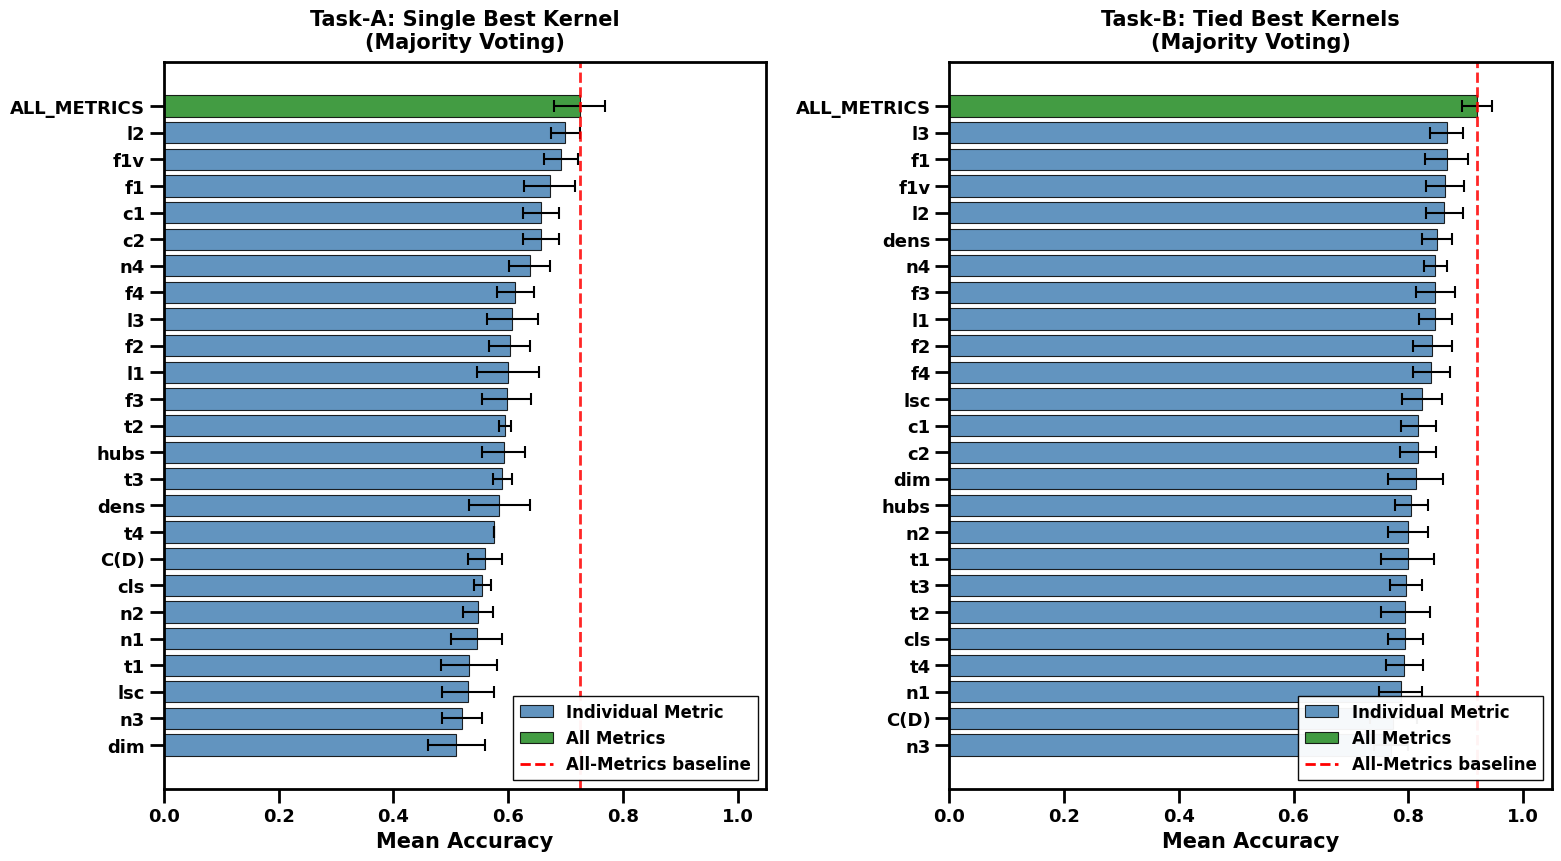

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

all_metrics_1a = df_1a_single[df_1a_single['Metric'] == 'ALL_METRICS'].iloc[0]
all_metrics_1b = df_1b_single[df_1b_single['Metric'] == 'ALL_METRICS'].iloc[0]

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.linewidth': 2.0,        # khung viền dày
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size': 10,
    'ytick.major.size': 10,
    'font.weight': 'bold',        # chữ đậm toàn cục
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

fig, axes = plt.subplots(1, 2, figsize=(16, 9))  


COLOR_SINGLE = 'steelblue'
COLOR_ALL    = 'forestgreen'

def plot_panel(ax, df_plot, all_metrics_row, title):
    colors = [COLOR_ALL if m == 'ALL_METRICS' else COLOR_SINGLE 
              for m in df_plot['Metric']]
    
    ax.barh(
        range(len(df_plot)),
        df_plot['Mean_Acc'],
        xerr=df_plot['Std_Acc'],
        color=colors,
        capsize=4,
        alpha=0.85,
        edgecolor='black',        
        linewidth=0.8,
        error_kw=dict(elinewidth=1.5, ecolor='black', capthick=1.5)
    )
    
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot['Metric'], fontweight='bold')
    ax.set_xlabel('Mean Accuracy', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)
    
    # Reference line
    ax.axvline(
        x=all_metrics_row['Mean_Acc'],
        color='red', linestyle='--', linewidth=2.0,
        alpha=0.85, label='_nolegend_'
    )
    
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    
    # ── Legend 
    patch_single = mpatches.Patch(
        facecolor=COLOR_SINGLE, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='Individual Metric'
    )
    patch_all = mpatches.Patch(
        facecolor=COLOR_ALL, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='All Metrics'
    )
    line_ref = plt.Line2D(
        [], [], color='red', linestyle='--', linewidth=2.0,
        label=f'All-Metrics baseline'
    )
    ax.legend(
        handles=[patch_single, patch_all, line_ref],
        loc='lower right',
        framealpha=0.95,
        edgecolor='black',
        fancybox=False,
        fontsize=12
    )
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

display_map = {
    'density': 'dens',
    'clsCoef': 'cls',
    'kolmogorov': 'C(D)',
    'intrinsic': 'dim'
}

# Task-A
df_plot_1a = df_1a_single.copy()
df_plot_1a['Metric'] = df_plot_1a['Metric'].replace(display_map)
plot_panel(axes[0], df_plot_1a, all_metrics_1a,
           'Task-A: Single Best Kernel\n(Majority Voting)')

# Task-B
df_plot_1b = df_1b_single.copy()
df_plot_1b['Metric'] = df_plot_1b['Metric'].replace(display_map)
plot_panel(axes[1], df_plot_1b, all_metrics_1b,
           'Task-B: Tied Best Kernels\n(Majority Voting)')

plt.tight_layout(pad=1.5)
plt.savefig('majority_voting_single_vs_all_metrics with benchmark_datasets_0.01.png', dpi=300, bbox_inches='tight')
plt.show()

## Predict for New Dataset (Task-B)

Sau khi đánh giá xong accuracy của framework qua cross-validation, bước này huấn luyện final models trên **toàn bộ** tập Task-B (không split) để sử dụng cho inference trên datasets mới.

Hai bộ models được train song song:
1. **All Metrics**: dùng toàn bộ 24 features
2. **Best Single Metric**: chỉ dùng metric đơn lẻ tốt nhất từ kết quả đánh giá trước đó

Cả hai đều fit StandardScaler trên toàn bộ X_1b trước khi train — đây là scaler sẽ được dùng lại khi transform dữ liệu mới.

In [14]:
from Qsun.Qkernels import *
from Qsun.Qencodes import *
from Qsun.Qdata import *
from src.kernel_evaluation import *
import problexity as px

In [15]:
print("=" * 70)
print("TRAIN ALL METRICS MODEL FOR TASK-B")
print("=" * 70)

scaler_1b_final = StandardScaler()
X_1b_scaled_final = scaler_1b_final.fit_transform(X_1b)

trained_models_1b_final = {}
for name, clf in CLASSIFIERS.items():
    try:
        model = clone(clf)
        model.fit(X_1b_scaled_final, y_1b_encoded)
        trained_models_1b_final[name] = model
    except Exception as e:
        print(f"  ✗ {name}: {e}")

print(f"✓ Trained {len(trained_models_1b_final)} classifiers on ALL METRICS")

TRAIN ALL METRICS MODEL FOR TASK-B
✓ Trained 14 classifiers on ALL METRICS


In [16]:
print("=" * 70)
print(f"TRAIN SINGLE METRIC ({best_singlemetric_1b}) MODEL FOR TASK-B")
print("=" * 70)

BEST_SINGLE_METRIC = best_singlemetric_1b
best_metric_idx = METRIC_NAMES.index(BEST_SINGLE_METRIC)

X_1b_single = X_1b[:, [best_metric_idx]]

scaler_1b_single = StandardScaler()
X_1b_single_scaled = scaler_1b_single.fit_transform(X_1b_single)

trained_models_1b_single = {}
for name, clf in CLASSIFIERS.items():
    try:
        model = clone(clf)
        model.fit(X_1b_single_scaled, y_1b_encoded)
        trained_models_1b_single[name] = model
    except Exception as e:
        print(f"  ✗ {name}: {e}")

print(f"✓ Trained {len(trained_models_1b_single)} classifiers on SINGLE METRIC ({BEST_SINGLE_METRIC})")

TRAIN SINGLE METRIC (f1) MODEL FOR TASK-B
✓ Trained 14 classifiers on SINGLE METRIC (f1)


### Ground Truth & Prediction Utilities

- `compute_ground_truth`: từ bảng kết quả chạy thực tế (kernel × model × dataset), xác định kernel(s) đạt accuracy cao nhất cho mỗi dataset. Đây là ground truth để đối chiếu với prediction của framework.

- `get_top_k_predictions_ensemble`: thay vì chỉ trả về 1 prediction (majority vote), hàm này trả về top-k kernels kèm xác suất (tỷ lệ phiếu bầu / tổng số classifiers). Dùng để đánh giá Top-1 và Top-3 hit rate.

- `prepare_dataset`: chuẩn hóa dữ liệu về [0, 1] bằng MinMaxScaler, sau đó giảm chiều bằng PCA nếu số features > 4 (giới hạn số qubits cho quantum kernel computation).

In [17]:
from src.config import *
from src.kernel_evaluation import *

In [18]:
def compute_ground_truth(df_all_results):
    ground_truth = {}
    
    for ds_name, ds_group in df_all_results.groupby('Dataset'):
        kernel_best = ds_group.groupby('Kernel')['Mean_Acc'].max()
        
        global_best_acc = kernel_best.max()
        
        best_kernels = kernel_best[kernel_best == global_best_acc].index.tolist()
        
        ground_truth[ds_name] = best_kernels
    
    return ground_truth


In [19]:
from collections import Counter

def get_top_k_predictions_ensemble(X_scaled, trained_models, label_encoder, top_k=3):
    votes = []
    for name, model in trained_models.items():
        try:
            pred_encoded = model.predict(X_scaled)[0]
            votes.append(pred_encoded)
        except Exception:
            pass

    vote_counts  = Counter(votes)
    total_votes  = len(votes)
    kernel_proba = []
    for kernel_encoded, count in vote_counts.items():
        kernel_label = str(label_encoder.inverse_transform([kernel_encoded])[0])
        probability  = count / total_votes
        kernel_proba.append((kernel_label, probability))

    kernel_proba.sort(key=lambda x: x[1], reverse=True)
    return kernel_proba[:top_k]


### Prepare Test Datasets

7 datasets mới được tạo để kiểm chứng khả năng inference của framework trên dữ liệu chưa từng thấy. Các datasets bao gồm nhiều dạng phân bố khác nhau: linear separable, non-linear (moons, circles, concentric rings), high-dimensional (digits), imbalanced classes, và Gaussian quantiles.

Tất cả đều được chuẩn hóa về [0, 1] và giới hạn tối đa 4 features (qua PCA nếu cần) để tương thích với quantum kernel computation.

In [20]:
from sklearn.datasets import load_digits, make_moons, make_circles, make_classification
from sklearn.datasets import make_gaussian_quantiles
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

def prepare_dataset(X, y, name, max_features=4):
    scaler_prep = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler_prep.fit_transform(X)
    if X_scaled.shape[1] > max_features:
        pca = PCA(n_components=max_features)
        X_scaled = pca.fit_transform(X_scaled)
        print(f"  {name}: {X.shape} → PCA → {X_scaled.shape} ({pca.explained_variance_ratio_.sum():.1%} var)")
    else:
        print(f"  {name}: {X_scaled.shape}")
    return X_scaled, y

print("=" * 70)
print("PREPARE ALL 7 TEST DATASETS")
print("=" * 70)

digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X_digits, y_digits = prepare_dataset(digits.data[mask], digits.target[mask], "Digits_0v1")

X_moons, y_moons = make_moons(n_samples=200, noise=0.35, random_state=42)
X_moons, y_moons = prepare_dataset(X_moons, y_moons, "Moons_n35")

X_circles, y_circles = make_circles(n_samples=200, noise=0.30, factor=0.3, random_state=42)
X_circles, y_circles = prepare_dataset(X_circles, y_circles, "Circles")

X_synth, y_synth = make_classification(
    n_samples=200, n_features=4, n_informative=3,
    n_redundant=1, flip_y=0.1, random_state=42
)
X_synth, y_synth = prepare_dataset(X_synth, y_synth, "Synthetic")

X_gauss, y_gauss = make_gaussian_quantiles(
    n_samples=150, n_features=3, n_classes=2, random_state=42
)
X_gauss, y_gauss = prepare_dataset(X_gauss, y_gauss, "GaussianQuantiles")

np.random.seed(42)
n_per_ring = 50
X_rings, y_rings = [], []
for i, r in enumerate([0.3, 0.6, 0.9]):
    theta = np.random.uniform(0, 2*np.pi, n_per_ring)
    X_ring = np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    X_ring += np.random.normal(0, 0.03, X_ring.shape)
    X_rings.append(X_ring)
    y_rings.extend([i % 2] * n_per_ring)
X_multiring = np.vstack(X_rings)
y_multiring = np.array(y_rings)
X_multiring, y_multiring = prepare_dataset(X_multiring, y_multiring, "MultiRing")

X_imbal, y_imbal = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    weights=[0.8, 0.2], class_sep=1.5, random_state=42
)
X_imbal, y_imbal = prepare_dataset(X_imbal, y_imbal, "Imbalanced")

all_test_datasets = {
    'Digits_0v1':        (X_digits,    y_digits),
    'Moons_n35':         (X_moons,     y_moons),
    'Circles':           (X_circles,   y_circles),
    'Synthetic':         (X_synth,     y_synth),
    'GaussianQuantiles': (X_gauss,     y_gauss),
    'MultiRing':         (X_multiring, y_multiring),
    'Imbalanced':        (X_imbal,     y_imbal),
}

print(f"\n Prepared {len(all_test_datasets)} test datasets")


PREPARE ALL 7 TEST DATASETS
  Digits_0v1: (360, 64) → PCA → (360, 4) (71.6% var)
  Moons_n35: (200, 2)
  Circles: (200, 2)
  Synthetic: (200, 4)
  GaussianQuantiles: (150, 3)
  MultiRing: (150, 2)
  Imbalanced: (100, 2)

 Prepared 7 test datasets


### Compute Complexity Metrics for Test Datasets

Tính 24 complexity metrics cho mỗi dataset test. Mỗi dataset được chạy 10 lần qua Problexity rồi lấy trung bình — giảm variance do một số metrics có tính stochastic.

Kết quả tạo thành ma trận `df_all_test_complexity` (7 × 24) — đây là input features cho bước prediction.

In [21]:
print("\n" + "=" * 70)
print(f"{'Dataset':<20} {'Samples':>8} {'Features':>10} {'Class 0':>8} {'Class 1':>8} {'Balance':>8}")
print("-" * 70)

for name, (X, y) in all_test_datasets.items():
    cls = np.bincount(y)
    bal = min(cls) / max(cls)
    print(f"{name:<20} {len(y):>8} {X.shape[1]:>10} {cls[0]:>8} {cls[1]:>8} {bal:>8.2f}")

print("=" * 70)
print("\n" + "=" * 70)
print("COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS")
print("=" * 70)

complexities_test = {}

for name, (X, y) in all_test_datasets.items():
    print(f"\n  {name}: shape={X.shape}")
    
    complexities_runs = []
    for i in range(10):
        cc = px.ComplexityCalculator()
        cc.fit(X, y)
        results = list(cc.complexity)
        results.append(kolmogorov_complex(X)['best_bytes'])
        results.append(intrinsic_dim_from_cov(X))
        complexities_runs.append(results)
    
    complexities_runs = np.array(complexities_runs)
    complexities_test[name] = np.mean(complexities_runs, axis=0)
    print(f"     Computed {len(METRIC_NAMES)} metrics")

df_all_test_complexity = pd.DataFrame(complexities_test, index=METRIC_NAMES).T
print(f"\n Complexity matrix: {df_all_test_complexity.shape}")
print(df_all_test_complexity.round(4).to_string())



Dataset               Samples   Features  Class 0  Class 1  Balance
----------------------------------------------------------------------
Digits_0v1                360          4      178      182     0.98
Moons_n35                 200          2      100      100     1.00
Circles                   200          2      100      100     1.00
Synthetic                 200          4      103       97     0.94
GaussianQuantiles         150          3       75       75     1.00
MultiRing                 150          2      100       50     0.50
Imbalanced                100          2       80       20     0.25

COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS

  Digits_0v1: shape=(360, 4)
     Computed 24 metrics

  Moons_n35: shape=(200, 2)
     Computed 24 metrics

  Circles: shape=(200, 2)
     Computed 24 metrics

  Synthetic: shape=(200, 4)
     Computed 24 metrics

  GaussianQuantiles: shape=(150, 3)
     Computed 24 metrics

  MultiRing: shape=(150, 2)
     Computed 24 metrics



### Ground Truth: Exhaustive Kernel Evaluation

Chạy brute-force toàn bộ 9 kernels × 3 ML models × 10 runs trên mỗi dataset test để xác định ground truth — kernel nào thực sự tốt nhất.

Quy trình mỗi run: split 80/20 → scale về [0, π] → tính quantum kernel matrix → evaluate bằng SVM, GPC, KRC. Ground truth = kernel(s) đạt max accuracy trung bình.

Đây là bước tốn thời gian nhất nhưng cần thiết để đánh giá chính xác: framework có recommend đúng kernel không?

In [22]:
N_VERIFY_RUNS = 10
ML_MODELS = list(MODEL_REGISTER.keys())
print("\n" + "=" * 70)
print(f"GROUND TRUTH: ALL KERNELS × ALL MODELS ({N_VERIFY_RUNS} runs)")
print("=" * 70)

all_results_7 = []

for ds_name, (X, y) in all_test_datasets.items():
    print(f"\n{'='*70}\n  {ds_name}\n{'='*70}")
    
    kernel_model_scores = {k: {m: [] for m in ML_MODELS} for k in ENCODING_REGISTER.keys()}
    
    for run in range(N_VERIFY_RUNS):
        seed = 42 + run
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        scaler_pi = MinMaxScaler(feature_range=(0, np.pi))
        X_tr_pi = scaler_pi.fit_transform(X_tr)
        X_te_pi = scaler_pi.transform(X_te)
        
        for kernel_name in ENCODING_REGISTER.keys():
            try:
                K_train, K_test = kernel_matrix(X_tr_pi, X_te_pi, kernel_name, n_layers=2)
                for model_name in ML_MODELS:
                    try:
                        result = evaluate_kernel(K_train, K_test, y_tr, y_te, kernel_name, model_name)
                        kernel_model_scores[kernel_name][model_name].append(result.test_accuracy)
                    except: pass
            except: pass
    
    print(f"\n{'Kernel':<22} {'SVM':>12} {'GPC':>12} {'KRC':>12} {'Avg':>12}")
    print("-" * 70)
    
    for kernel_name in ENCODING_REGISTER.keys():
        row = f"{kernel_name:<22}"
        model_means = []
        for model_name in ML_MODELS:
            scores = kernel_model_scores[kernel_name][model_name]
            if scores:
                m, s = np.mean(scores), np.std(scores)
                model_means.append(m)
                row += f" {m:.4f}±{s:.2f}"
                all_results_7.append({
                    'Dataset': ds_name, 'Kernel': kernel_name,
                    'Model': model_name, 'Mean_Acc': m, 'Std_Acc': s
                })
            else:
                row += f" {'N/A':>12}"
        if model_means:
            row += f" {np.mean(model_means):.4f}"
        print(row)

df_results_7 = pd.DataFrame(all_results_7)


GROUND TRUTH: ALL KERNELS × ALL MODELS (10 runs)

  Digits_0v1

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.5014±0.05 0.5000±0.07 0.4903±0.05 0.4972
HighDim                1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
HZY_CZ                 0.9958±0.01 0.9958±0.01 0.9972±0.01 0.9963
Chebyshev              0.5597±0.06 0.5722±0.05 0.5542±0.06 0.5620
ParamZFeatureMap       0.7097±0.06 0.7139±0.05 0.7000±0.06 0.7079
SeparableRX            0.9986±0.00 0.9944±0.01 0.9972±0.01 0.9968
HardwareEfficientRx    1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
ZFeatureMap            0.9722±0.02 0.9639±0.02 0.9792±0.02 0.9718
ZZFeatureMap           0.8972±0.04 0.8556±0.06 0.8889±0.03 0.8806

  Moons_n35

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.4525±0.09 

In [23]:
ground_truth_7 = compute_ground_truth(df_results_7)

print("\n" + "=" * 70)
print("BEST KERNELS PER DATASET")
print("=" * 70)

for ds_name, best_kernels in ground_truth_7.items():
    ds_res = df_results_7[df_results_7['Dataset'] == ds_name]
    kernel_best = ds_res.groupby('Kernel')['Mean_Acc'].max()
    best_acc = kernel_best.max()
    print(f"\n{ds_name}: best={best_acc:.4f}")
    for k in best_kernels:
        print(f"    {k}: {kernel_best[k]:.4f}")


BEST KERNELS PER DATASET

Circles: best=0.8800
    HighDim: 0.8800

Digits_0v1: best=1.0000
    HardwareEfficientRx: 1.0000
    HighDim: 1.0000

GaussianQuantiles: best=0.9400
    HardwareEfficientRx: 0.9400

Imbalanced: best=0.9950
    HighDim: 0.9950

Moons_n35: best=0.8600
    HighDim: 0.8600

MultiRing: best=0.9867
    ZFeatureMap: 0.9867

Synthetic: best=0.8625
    HardwareEfficientRx: 0.8625
    HighDim: 0.8625
    SeparableRX: 0.8625


### Predictions vs Ground Truth

So sánh prediction của framework với ground truth trên 7 datasets test. Mỗi dataset được dự đoán bằng cả hai bộ models (All Metrics và Best Single Metric), lấy top-3 predictions.

Đánh giá theo hai tiêu chí:
- **Top-1 Hit**: kernel được recommend nhiều phiếu nhất có nằm trong ground truth không?
- **Top-3 Hit**: có bất kỳ kernel nào trong top-3 predictions nằm trong ground truth không?

Top-3 Hit là metric thực tế hơn — trong ứng dụng, người dùng có thể thử 2-3 kernels được recommend thay vì chạy hết 9.

In [24]:
print("\n" + "=" * 70)
print("PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)")
print("=" * 70)

predictions_7 = []

for ds_name in all_test_datasets.keys():
    # All metrics
    X_new = df_all_test_complexity.loc[ds_name, feature_cols].values.reshape(1, -1)
    X_new_scaled = scaler_1b_final.transform(X_new)
    top3_all = get_top_k_predictions_ensemble(X_new_scaled, trained_models_1b_final, le_1b, top_k=3)

    # Single metric
    X_single = np.array([[df_all_test_complexity.loc[ds_name, BEST_SINGLE_METRIC]]])
    X_single_scaled = scaler_1b_single.transform(X_single)
    top3_single = get_top_k_predictions_ensemble(X_single_scaled, trained_models_1b_single, le_1b, top_k=3)

    gt = ground_truth_7[ds_name]
    mv_top1 = top3_all[0][0] in gt
    mv_top3 = any(k in gt for k, _ in top3_all)
    sg_top1 = top3_single[0][0] in gt
    sg_top3 = any(k in gt for k, _ in top3_single)

    predictions_7.append({
        'Dataset':            ds_name,
        'GT_Best':            gt,
        'MV_All_Top1':        top3_all[0][0],
        'MV_All_Top3':        [k for k, _ in top3_all],
        'MV_Single_Top1':     top3_single[0][0],
        'MV_Single_Top3':     [k for k, _ in top3_single],
        'MV_All_Top1_Hit':    mv_top1,
        'MV_All_Top3_Hit':    mv_top3,
        'MV_Single_Top1_Hit': sg_top1,
        'MV_Single_Top3_Hit': sg_top3,
    })

    print(f"\n{ds_name}:")
    print(f"  GT:             {gt}")
    print(f"  MV All  Top-3:  {[k for k,_ in top3_all]}  Top-1={'✓' if mv_top1 else '✗'} Top-3={'✓' if mv_top3 else '✗'}")
    print(f"  MV Single Top-3:{[k for k,_ in top3_single]}  Top-1={'✓' if sg_top1 else '✗'} Top-3={'✓' if sg_top3 else '✗'}")



PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)

Digits_0v1:
  GT:             ['HardwareEfficientRx', 'HighDim']
  MV All  Top-3:  ['HighDim', 'SeparableRX', 'HZY_CZ']  Top-1=✓ Top-3=✓
  MV Single Top-3:['HighDim', 'HZY_CZ', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓

Moons_n35:
  GT:             ['HighDim']
  MV All  Top-3:  ['HighDim']  Top-1=✓ Top-3=✓
  MV Single Top-3:['HighDim']  Top-1=✓ Top-3=✓

Circles:
  GT:             ['HighDim']
  MV All  Top-3:  ['SeparableRX', 'HighDim', 'HardwareEfficientRx']  Top-1=✗ Top-3=✓
  MV Single Top-3:['SeparableRX', 'HighDim', 'HZY_CZ']  Top-1=✗ Top-3=✓

Synthetic:
  GT:             ['HardwareEfficientRx', 'HighDim', 'SeparableRX']
  MV All  Top-3:  ['HighDim', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓
  MV Single Top-3:['HighDim', 'SeparableRX']  Top-1=✓ Top-3=✓

GaussianQuantiles:
  GT:             ['HardwareEfficientRx']
  MV All  Top-3:  ['HighDim', 'HardwareEfficientRx', 'ZFeatureMap']  Top-1=✗ Top-3=✓
  MV Single Top-3:['ZZFeatureMap', 'HighDim'

In [25]:
df_pred_7 = pd.DataFrame(predictions_7)
n = len(df_pred_7)

print("\n" + "=" * 70)
print(f"FINAL SUMMARY ({n} DATASETS)")
print("=" * 70)
for label, col_top1, col_top3 in [
    ("Majority Voting (All Metrics)",                    'MV_All_Top1_Hit',    'MV_All_Top3_Hit'),
    (f"Majority Voting (Single - {BEST_SINGLE_METRIC})", 'MV_Single_Top1_Hit', 'MV_Single_Top3_Hit'),
]:
    t1 = df_pred_7[col_top1].sum()
    t3 = df_pred_7[col_top3].sum()
    print(f"\n{label}:")
    print(f"  Top-1: {t1}/{n} ({t1/n*100:.1f}%)")
    print(f"  Top-3: {t3}/{n} ({t3/n*100:.1f}%)")


FINAL SUMMARY (7 DATASETS)

Majority Voting (All Metrics):
  Top-1: 4/7 (57.1%)
  Top-3: 7/7 (100.0%)

Majority Voting (Single - f1):
  Top-1: 4/7 (57.1%)
  Top-3: 5/7 (71.4%)
